# ==========================================
# Task 3: Customer Churn Prediction
# ==========================================

print("Task 3: Customer Churn Prediction")
print("This project identifies bank customers who are likely to leave the bank.")

# Objective

print("""
Objective:
The objective of this project is to identify customers who are likely to leave the bank.

This project aims to:
1. Load and understand the Churn Modelling dataset.
2. Clean and prepare the dataset.
3. Encode categorical features such as Geography and Gender.
4. Train a classification model.
5. Analyze feature importance to understand what influences churn.
""")

In [1]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nDesktop Files:")
print(os.listdir("../"))

Current Folder:
/Users/yasirkhan

Desktop Files:
['.localized', 'Shared', 'yasirkhan']


In [2]:
import os

print(os.listdir("/Users/yasirkhan/Desktop"))

['Momina programing project.py', '~$ SYSTEM ANALYSIS.docx', 'IMG_9957-removebg-preview.png', '~$APDP.docx', 'Test Prep 2.docx', '~$2.docx', 'APDP Project.zip', '~$search  paper .docx', '.DS_Store', 'PHOTO-2026-05-04-22-45-50.jpg', '~$estion paper.docx', '~$e Research Proposal.docx', '~$search Paper.docx', 'SS.docx', '.localized', '~$ck Dorsey revised .docx', 'Screenshot 2026-06-10 at 1.40.50\u202fpm.png', 'Doc1.docx', '~$ssiness doc .docx', '~$ototyping .docx', 'Screenshot 2026-06-10 at 2.02.57\u202fpm.png', 'yasir cv ', '95c6d482-a1f3-4908-9ee0-a7d482d40de1.JPG', 'Churn_Modelling.csv', 'YDS Data Analysis Tool.py', 'addmistion doc ', 'otline.pdf', '~$5.docx', '~$G BOOK .docx', 'YASIR KHAN CRP', 'BPS-1.zip', 'Screenshot 2026-06-04 at 2.50.01\u202fpm.png', 'Documents ', 'HND level  5', 'momina-portfolio.html', '98dac6af-e0be-4acc-bbdf-d4ad2b477f13.JPG', 'german A1 ', 'Design Doc DDD.docx', '.ipynb_checkpoints', '~$0-APDP.docx', '~$search Proposal.docx', '~$o math.docx', 'yasir_khan_cv.jp

In [3]:
import pandas as pd

df = pd.read_csv("/Users/yasirkhan/Desktop/Churn_Modelling.csv")

print("Dataset Loaded Successfully")
print(df.shape)

df.head()

Dataset Loaded Successfully
(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
df.fillna(method='ffill', inplace=True)

print("Missing Values Handled")

Missing Values Handled


/var/folders/22/fvr61vqx19l3ktt6mmyck72m0000gn/T/ipykernel_36634/1328118278.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [7]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Geography'] = le.fit_transform(df['Geography'])

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


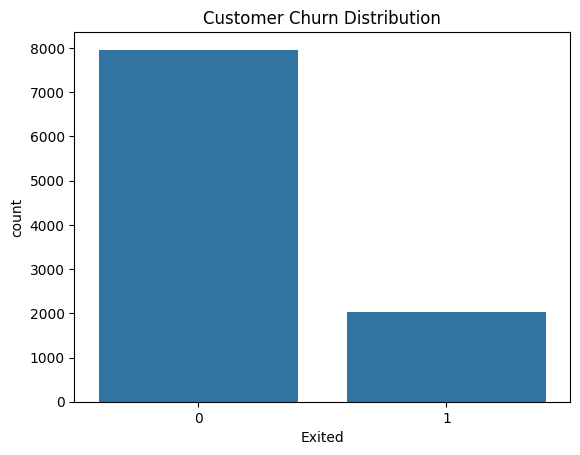

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Exited', data=df)

plt.title("Customer Churn Distribution")
plt.show()

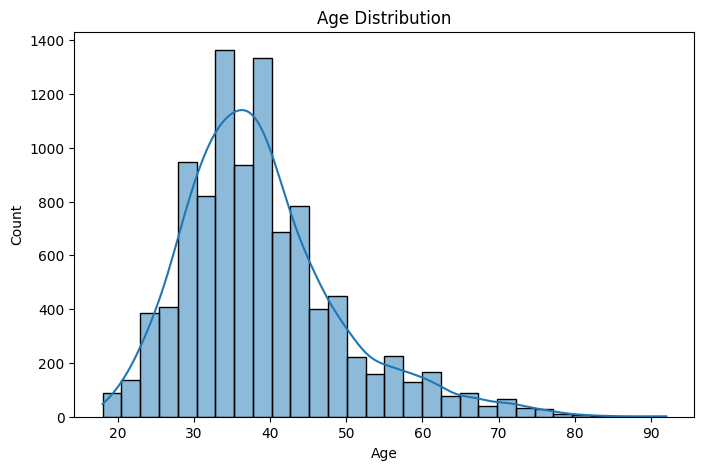

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.show()

In [13]:
X = df.drop('Exited', axis=1)
y = df['Exited']

print(X.shape)
print(y.shape)

(10000, 10)
(10000,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8000, 10)
Testing Data: (2000, 10)


In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [16]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8645


In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1545   62]
 [ 209  184]]


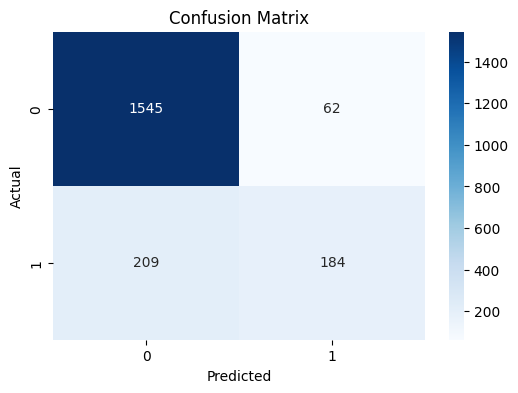

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



# Conclusion

The Customer Churn Prediction model was developed using the Random Forest Classification algorithm.

The dataset was cleaned and preprocessed by removing unnecessary columns and encoding categorical variables into numerical values.

Exploratory Data Analysis (EDA) was performed to understand customer demographics and churn patterns.

The Random Forest model achieved a good prediction accuracy, demonstrating its effectiveness in identifying customers likely to leave the bank.

The confusion matrix and classification report were used to evaluate model performance and classification quality.

This project demonstrates how machine learning can help businesses identify at-risk customers and improve customer retention strategies.